# 데이터 기초 특성 파악

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import koreanize_matplotlib

In [2]:
raw = pd.read_csv('prj_data.csv')
raw.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,메모,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,재구매 유도 대상,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,재구매 유도 대상,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,NaN,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,재구매 유도 대상,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,NaN,0


In [3]:
raw.shape

(500, 12)

In [4]:
raw.dtypes

고객ID           str
나이         float64
성별             str
거주지역           str
가입경로           str
멤버십등급          str
월평균구매금액    float64
구매횟수       float64
리뷰점수       float64
쿠폰사용여부         str
메모             str
이탈여부         int64
dtype: object

In [5]:
raw.describe()

,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부
count,460.000000,500.000000,500.000000,475.000000,500.000000
mean,43.195652,97684.003413,7.822000,3.736632,0.380000
std,14.998358,106309.940848,4.481795,0.554389,0.485873
min,18.000000,19127.903927,1.000000,2.500000,0.000000
25%,30.000000,48362.456334,4.000000,3.400000,0.000000
50%,43.000000,74770.324856,7.000000,3.700000,0.000000
75%,56.250000,114551.098353,10.250000,4.100000,1.000000
max,69.000000,945072.807028,21.000000,5.000000,1.000000


In [6]:
num_cols = raw.select_dtypes(include='number').columns.tolist()
cat_cols = raw.select_dtypes(exclude='number').columns.tolist()
num_cols, cat_cols

(['나이', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부'],
 ['고객ID', '성별', '거주지역', '가입경로', '멤버십등급', '쿠폰사용여부', '메모'])

In [7]:
raw['쿠폰사용여부'].value_counts()

쿠폰사용여부
N    310
Y    190
Name: count, dtype: int64

# 단변량/분포 시각화

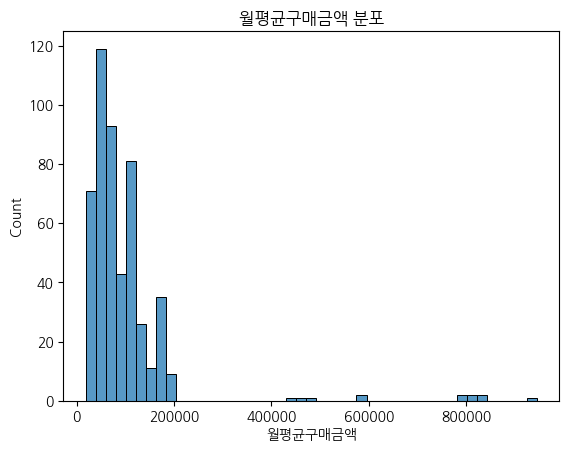

In [9]:
sns.histplot(data=raw['월평균구매금액'])
plt.title('월평균구매금액 분포')
plt.show()

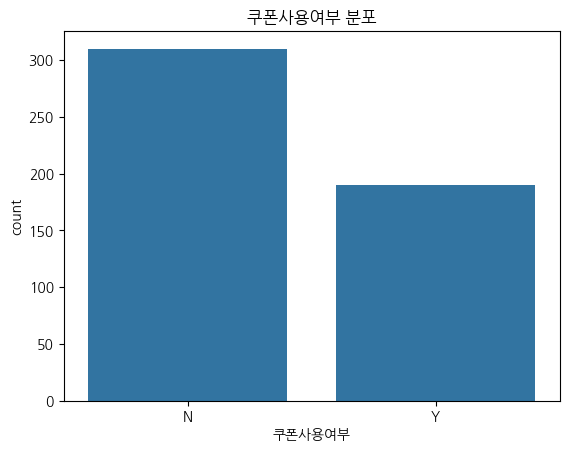

In [11]:
sns.countplot(data=raw, x=raw['쿠폰사용여부'])
plt.title('쿠폰사용여부 분포')
plt.show()

In [1]:
print('1) 월평균구매금액은 200,000원 이하에 치우쳐져 있으며, 높은 금액 쪽에 이상치로 볼 수 있는 데이터가 소수 있지만 충분히 존재할 수 있는 데이터이다')
print('2) 구매 시 쿠폰을 사용 하지 않은 사람들이 더 많다')

1) 월평균구매금액은 200,000원 이하에 치우쳐져 있으며, 높은 금액 쪽에 이상치로 볼 수 있는 데이터가 소수 있지만 충분히 존재할 수 있는 데이터이다
2) 구매 시 쿠폰을 사용 하지 않은 사람들이 더 많다


# 상관관계 및 이변량 분석

<Axes: >

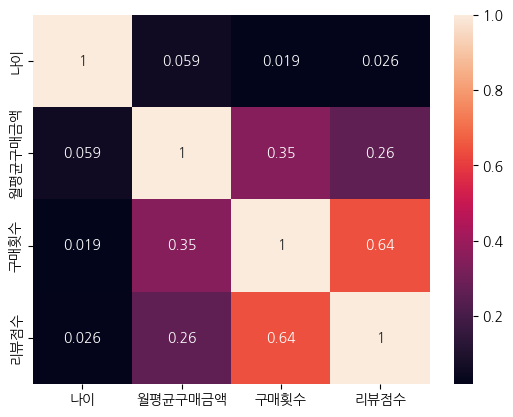

In [ ]:
corr = raw[['나이', '월평균구매금액', '구매횟수', '리뷰점수']].corr()
sns.heatmap(corr, annot=True)

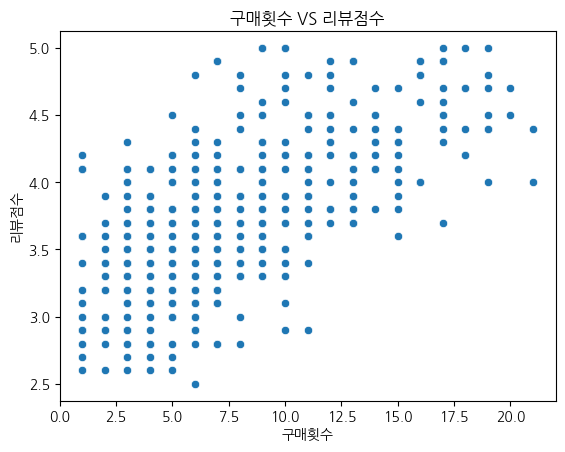

In [27]:
sns.scatterplot(data=raw, x=raw['구매횟수'], y=raw['리뷰점수'])
plt.title('구매횟수 VS 리뷰점수')
plt.show()

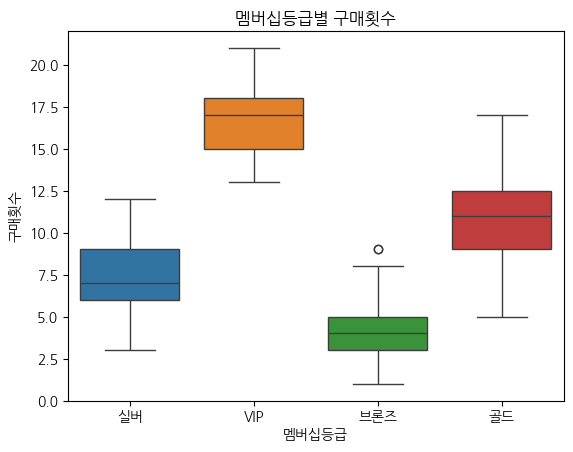

In [25]:
sns.boxplot(data=raw, x=raw['멤버십등급'], y=raw['구매횟수'], hue=raw['멤버십등급'])
plt.title('멤버십등급별 구매횟수')
plt.show()

In [ ]:
print('구매횟수와 리뷰점수의 상관관계가 가장 높다')
print('나이와 구매횟수의 상관관계가 가장 낮다')
print('하지만 무조건 구매를 많이 했기 때문에 리뷰점수가 높고, 나이가 많기 때문에 구매횟수가 높다고 볼 수는 없다')
print('구매를 1번 했어도 리뷰점수를 5점 줄 수 있고, 나이가 많아도 쇼핑을 즐기지 않는다면 구매횟수가 적을 수 있다')

구매횟수와 리뷰점수의 상관관계가 가장 높다
나이와 구매횟수의 상관관계가 가장 낮다
하지만 무조건 구매를 많이 했기 때문에 리뷰점수가 높고, 나이가 많기 때문에 구매횟수가 높다고 볼 수는 없다
구매를 1번 했어도 리뷰점수를 5점 줄 수 있고, 나이가 많아도 쇼핑을 즐기지 않는다면 구매횟수가 적을 수 있다


# 그룹별 비교 분석 및 인사이트 도출

In [49]:
g1 = raw.groupby('멤버십등급')['월평균구매금액'].mean()
g2 = raw.groupby('멤버십등급')['구매횟수'].mean()
g1, g2

(멤버십등급
 VIP    179391.538815
 골드     132284.955111
 브론즈     56673.984832
 실버      94439.661736
 Name: 월평균구매금액, dtype: float64,
 멤버십등급
 VIP    16.654545
 골드     10.774775
 브론즈     4.072917
 실버      7.161972
 Name: 구매횟수, dtype: float64)

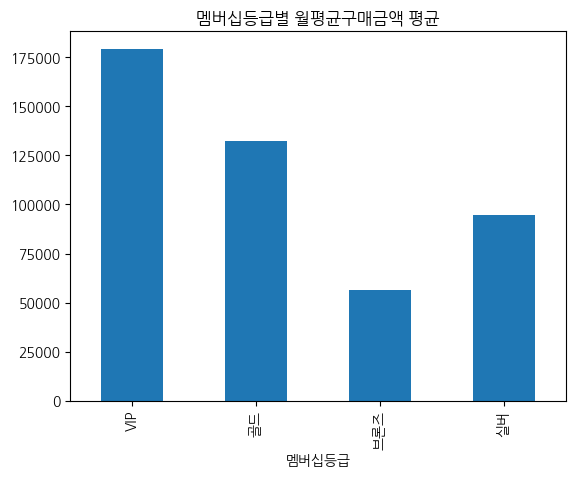

In [44]:
g1.plot(kind='bar')
plt.title('멤버십등급별 월평균구매금액 평균')
plt.show()

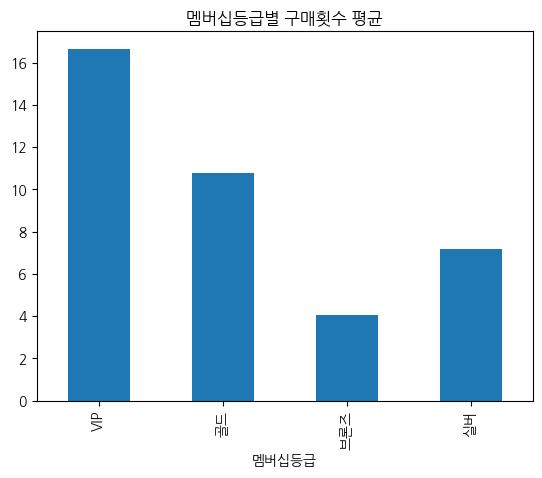

In [50]:
g2.plot(kind='bar')
plt.title('멤버십등급별 구매횟수 평균')
plt.show()

In [51]:
print('1) 멤버십등급이 높을수록 월평균구매금액과 구매횟수가 높다')
print('2) 구매횟수와 리뷰점수의 상관관계를 보았을 때, 구매횟수가 많을수록 리뷰점수가 높은 쪽에 많이 분포되어 있다')

1) 멤버십등급이 높을수록 월평균구매금액과 구매횟수가 높다
2) 구매횟수와 리뷰점수의 상관관계를 보았을 때, 구매횟수가 많을수록 리뷰점수가 높은 쪽에 많이 분포되어 있다
